In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
document = pd.read_csv("result.csv")
print(document.head())

   task  dataset  llm_summarizer  summarization_prompt  judging_llm  \
0  task  dataset  llm_summarizer  summarization_prompt  judging_llm   
1  task  dataset  llm_summarizer  summarization_prompt  judging_llm   
2  task  dataset  llm_summarizer  summarization_prompt  judging_llm   
3  task  dataset  llm_summarizer  summarization_prompt  judging_llm   
4  task  dataset  llm_summarizer  summarization_prompt  judging_llm   

   judging_prompt  metric  score  label  
0  judging_prompt  metric  score  label  
1  judging_prompt  metric  score  label  
2  judging_prompt  metric  score  label  
3  judging_prompt  metric  score  label  
4  judging_prompt  metric  score  label  


In [3]:
#document.info()
print(document.describe())
document.shape

        task  dataset  llm_summarizer  summarization_prompt judging_llm  \
count   1399     1399            1399                  1399        1399   
unique     5        5               4                     6           4   
top     task  dataset  llm_summarizer  summarization_prompt      llama4   
freq     379      379             379                   379         504   

       judging_prompt  metric score label  
count            1399    1399  1399  1399  
unique              2       5     4     5  
top        test_judge  metric     1  Good  
freq             1020     379   534   512  


(1399, 9)

In [5]:
df = document[document["task"] != "task"]
print(df.shape)
df.describe()

(1020, 9)


,task,dataset,llm_summarizer,summarization_prompt,judging_llm,judging_prompt,metric,score,label
count,1020,1020,1020,1020,1020,1020,1020,1020,1020
unique,4,4,3,5,3,1,4,3,4
top,SEMISUPERVISED,LL0_1053_jm1,gpt-4o-mini,zeroshot_CoT,llama4,test_judge,Accuracy,1,Good
freq,372,372,364,236,504,1020,255,534,512


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1020 entries, 10 to 1398
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   task                  1020 non-null   object
 1   dataset               1020 non-null   object
 2   llm_summarizer        1020 non-null   object
 3   summarization_prompt  1020 non-null   object
 4   judging_llm           1020 non-null   object
 5   judging_prompt        1020 non-null   object
 6   metric                1020 non-null   object
 7   score                 1020 non-null   object
 8   label                 1020 non-null   object
dtypes: object(9)
memory usage: 79.7+ KB


### RQ1: How does the summarization quality vary by LLM summarizer
Do some summarizer models(e,g, llama vs others) consistently score higher across metrics?

In [28]:
summarizer_score =  pd.crosstab(df["llm_summarizer"], [df["metric"], df["label"]], rownames=['llm'], colnames=['metric','label']) 
summarizer_score

metric          Accuracy                     Clarity                      \
label            Average Excellent Good Poor Average Excellent Good Poor   
llm                                                                        
deepseek-r1:14b       46         2   38    0      52         2   26    6   
gpt-4o-mini           38         6   45    2      38         4   35   14   
llama4                38         0   40    0      40         0   32    6   

metric          Completeness                     Relevance                 
label                Average Excellent Good Poor   Average Excellent Good  
llm                                                                        
deepseek-r1:14b           34         0   36   16        28         2   56  
gpt-4o-mini               28         2   47   14        18         6   67  
llama4                    32         0   28   18        16         0   62

In [23]:
test_judge =  pd.crosstab(df["judging_llm"], [df["metric"], df["label"]], rownames=['llm'], colnames=['metric','label']) 
test_judge

metric          Accuracy                     Clarity                      \
label            Average Excellent Good Poor Average Excellent Good Poor   
llm                                                                        
deepseek-r1:14b       42         8   42    2      44         6   20   24   
gpt-4o-mini            0         0   35    0       0         0   35    0   
llama4                80         0   46    0      86         0   38    2   

metric          Completeness                     Relevance                 
label                Average Excellent Good Poor   Average Excellent Good  
llm                                                                        
deepseek-r1:14b           48         2   28   16         4         8   82  
gpt-4o-mini               10         0   25    0         0         0   35  
llama4                    36         0   58   32        58         0   68

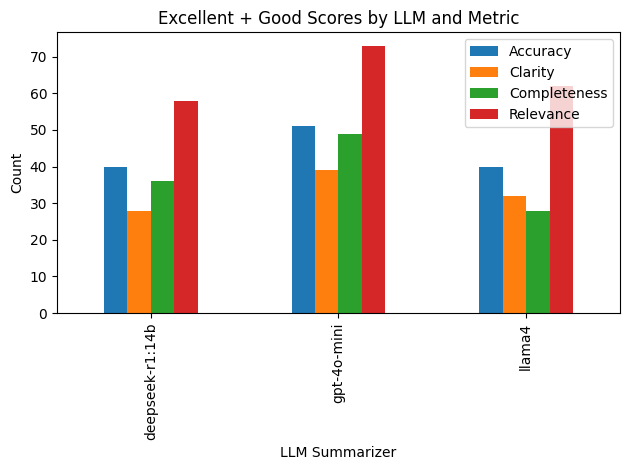

In [29]:
# Sum Excellent + Good per metric
summary = {}
for metric in ["Accuracy", "Clarity", "Completeness", "Relevance"]:
    summary[metric] = (
        summarizer_score[(metric, "Excellent")] +
        summarizer_score[(metric, "Good")]
    )

summary_df = pd.DataFrame(summary)

# Plot
summary_df.plot(kind="bar")
plt.title("Excellent + Good Scores by LLM and Metric")
plt.ylabel("Count")
plt.xlabel("LLM Summarizer")
plt.tight_layout()
plt.show()



gpt-4o-mini consistently scores the highest across all four metrics.
It leads in Accuracy, Clarity, Completeness, and Relevance.

llama4 is generally second-best:

Strong on Relevance and Accuracy

Slightly weaker on Completeness compared to deepseek-r1:14b

deepseek-r1:14b trails both:

Particularly weaker on Clarity and Completeness

Still reasonable on Relevance, but not competitive with gpt-4o-mini
gpt-4o-mini is the clear overall winner, while llama4 is a solid runner-up, and deepseek-r1:14b performs worst overall.

### RQ2: Does the choice of summarization prompt affect performance?
Compare zeroshot vs zeroshot_instruction (and others) across metrics.

In [35]:
summarization_prompt_score =  pd.crosstab(df["summarization_prompt"], [df["metric"], df["label"]], rownames=['Summarization Prompt'], colnames=['metric','label']) 
summarization_prompt_score 

metric               Accuracy                     Clarity                      \
label                 Average Excellent Good Poor Average Excellent Good Poor   
Summarization Prompt                                                            
chain_of_thought           22         2   25    0      26         2   17    4   
fewshot                    22         0   25    0      32         0   11    4   
zeroshot                   24         2   25    0      20         2   21    8   
zeroshot_CoT               28         4   25    2      32         2   21    4   
zeroshot_instruction       26         0   23    0      20         0   23    6   

metric               Completeness                     Relevance                 
label                     Average Excellent Good Poor   Average Excellent Good  
Summarization Prompt                                                            
chain_of_thought               24         0   17    8        12         2   35  
fewshot                        14         0   23   10        10         0   37  
zeroshot                       16         0   23   12        14         2   35  
zeroshot_CoT                   24         2   23   10        16         4   39  
zeroshot_instruction           16         0   25    8        10         0   39

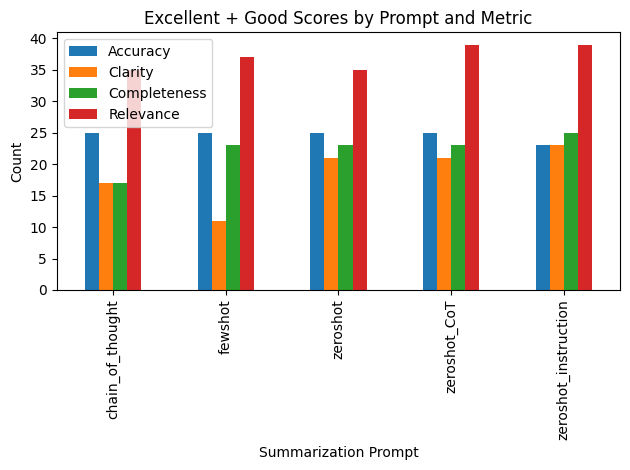

In [60]:
# Sum Excellent + Good per metric
summary = {}
for metric in ["Accuracy", "Clarity", "Completeness", "Relevance"]:
    summary[metric] = (
        summarization_prompt_score[(metric, "Good")]
    )
    
summary_df = pd.DataFrame(summary)

# Plot
summary_df.plot(kind="bar")
plt.title("Excellent + Good Scores by Prompt and Metric")
plt.ylabel("Count")
plt.xlabel("Summarization Prompt")
plt.tight_layout()
plt.show()


### Observation
zeroshot_CoT was consistent throught out the different metrics, 
## Let analyze the output of the different prompt by metric
## Accuracy
All the prompt has the same number of good with a count of 25 each except for zeroshot_instruction with a count of 23
zeroshot_CoT  has a greater count of average of accuracy, follow by zeroshot_instruction , and the least are fewshot and chain_of_thought
Only zeroshot_CoT and  chain_of_thought has excellent for accuracy but  zeroshot_CoT has the highest number of excellent

## Clarity
Zeroshot_instruction has the highest good count of 23 , and fewshot has the lowest good count of 11
Fewshot, zeroshot_CoT have the highest count of average. zeroshot has the lowest count. 
chain_of_thought, zeroshot and zeroshot_CoT obtained the same number of  execellent in the judgement

## Completeness
Zeroshot_instruction has the highest good count of 25, and chain of thought has the lowest count of 17
only zeroshot_CoT had an excellent judgement of the completeness

## Relevance
zeroshot_instruction , zeroshot_CoT has the highest count of 39 and the lowest chain_of_thought of count 35 (the difference is not that big)
zeroshot_CoT has the highest count of average in relevance, fewshot has the lowest count of average in relevance.

### Resume
Zeroshot_instruction was consistent through out the 4 metrics,  it had the highest score in Relevance, Completeness, Clarity, and accuracy
followed by zeroshot_CoT which  the judgement was consistent, it has the same number of good judgement as zeroshot_instruction in  the relevance and accuracy, it also has an excellent judgement in accuracy and completeness, though excellent was not define in the judging prompt.
Thirdly, we have zeroshot...



Zero-shot CoT (chain-of-thought) is the strongest and most balanced. Zero-shot instruction is very relevant, solid accuracy. zero-shot is consistent but weaker clarity/completeness. Few-shot is surprisingly weaker completeness. chain-of-thought is verbose, but less relevant.

Reasoning-augmented prompts (zeroshot_CoT) perform best overall, improving both average quality and peak (Excellent) outcomes.
Instruction-only prompts trade off excellence for consistency, yielding more “Good” but fewer standout results.
Simply adding examples (fewshot) or generic CoT is not enough—prompt structure and explicit reasoning guidance are critical.
This suggests that prompt design is a first-order factor in summarization quality, not a minor tuning detail

In [61]:
# # print(summarization_prompt_score.sum())
# perc_summarization_prompt_score  = summarization_prompt_score.div(summarization_prompt_score.sum()) * 100
# perc_summarization_prompt_score

In [62]:
# # Sum Excellent + Good per metric
# summary = {}
# for metric in ["Accuracy", "Clarity", "Completeness", "Relevance"]:
#     summary[metric] = (
#         perc_summarization_prompt_score[(metric, "Good")]
#     )
    
# summary_df = pd.DataFrame(summary)

# # Plot
# summary_df.plot(kind="bar")
# plt.title("Excellent + Good Scores by Prompt and Metric")
# plt.ylabel("% Percentage Count")
# plt.xlabel("Summarization Prompt")
# plt.tight_layout()
# plt.show()


label                 Average  Excellent  Good  Poor
summarization_prompt                                
chain_of_thought           84          6    94    12
fewshot                    78          0    96    14
zeroshot                   74          6   104    20
zeroshot_CoT              100         12   108    16
zeroshot_instruction       72          0   110    14


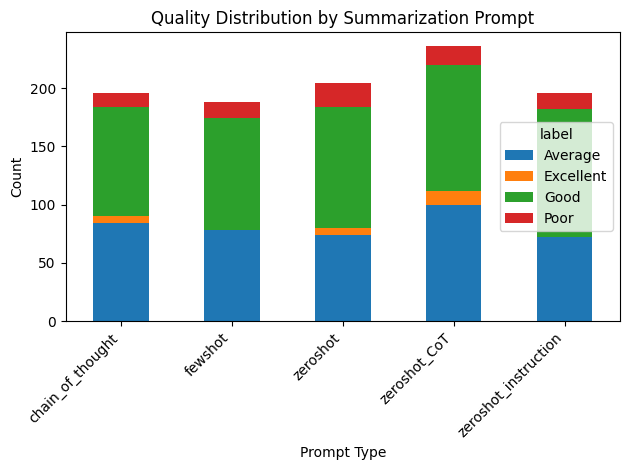

In [63]:
dist_prompt = (
    df.groupby(["summarization_prompt", "label"])
      .size()
      .unstack(fill_value=0)
)

print(dist_prompt)

dist_prompt.plot(kind="bar", stacked=True)
plt.title("Quality Distribution by Summarization Prompt")
plt.ylabel("Count")
plt.xlabel("Prompt Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### RQ3: Which evaluation metrics are hardest or easiest to satisfy?
Compare average scores for Acuracy, Clarity, Completeness, Revelance

label         Average  Excellent  Good  Poor
metric                                      
Accuracy          122          8   123     2
Clarity           130          6    93    26
Completeness       94          2   111    48
Relevance          62          8   185     0
metric
Accuracy        48.235294
Clarity         36.470588
Completeness    43.529412
Relevance       72.549020
Name: Good, dtype: float64


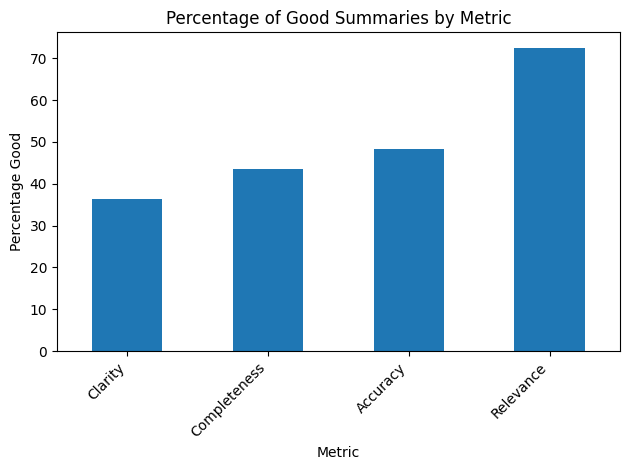

In [64]:
metric_counts = (
    df.groupby(["metric", "label"])
      .size()
      .unstack(fill_value=0)
)

print(metric_counts)
metric_good_pct = (metric_counts.div(metric_counts.sum(axis=1), axis=0)["Good"]) * 100
print(metric_good_pct)

plt.figure()
metric_good_pct.sort_values().plot(kind="bar")
plt.title("Percentage of Good Summaries by Metric")
plt.ylabel("Percentage Good")
plt.xlabel("Metric")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Relevance is the easiest metric to achieve, having zero count of poor with the highest number of good
Followed by the Accuracy , then the completeness which has the highest percentage of poor judgement but has a greater count of accuracy compare to the Clarity

### RQ4:  does the performance vary across datasets or tasks?
Check whether certain datasets or task types(e.g, SEMISUPERVISED) are harder to summarize


label            Average  Excellent  Good  Poor
dataset                                        
196_autoMpg          144          0    48    16
299_libras_move      138          0    44    42
LL0_1053_jm1          84         24   264     0
stock_market          42          0   156    18


<Axes: xlabel='dataset'>

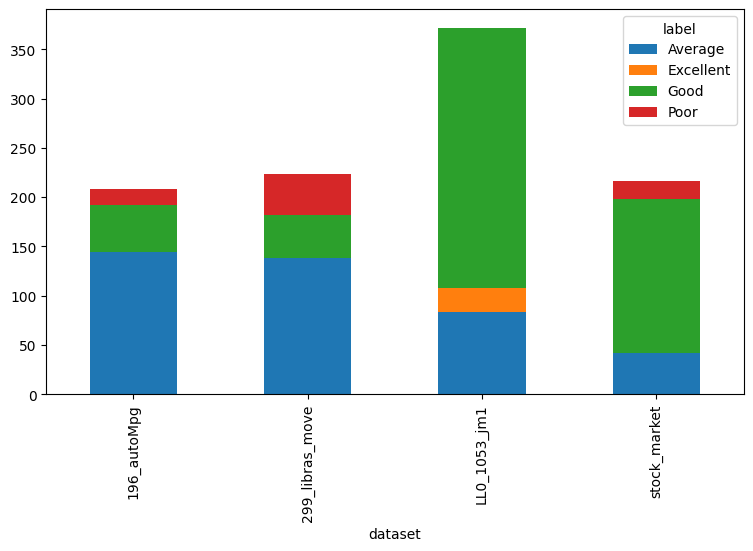

In [33]:
dist_dataset = pd.crosstab(df["dataset"], df["label"])
print(dist_dataset)

dist_dataset.plot(kind="bar", stacked=True, figsize=(9,5))

The dataset LL0_jm1, of the semi_surpived task has a greatest overall performance.

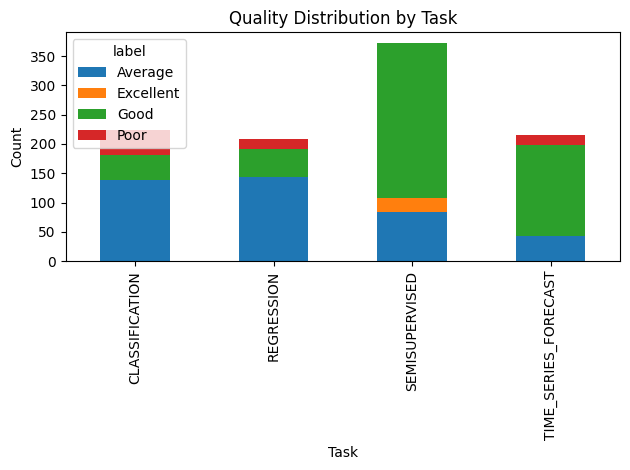

In [32]:
dist_dataset = (
    df.groupby(["task", "label"])
      .size()
      .unstack(fill_value=0)
)

dist_dataset.plot(kind="bar", stacked=True)
plt.title("Quality Distribution by Task")
plt.ylabel("Count")
plt.xlabel("Task")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### RQ5: Are some summarization-prompt/ llm_summarizer combinations particularly strong or weak?
Look at interaction effects between llm_summarizer and summarization_prompt

In [67]:
combo_counts = (
    df.groupby(["llm_summarizer", "summarization_prompt", "label"])
      .size()
      .reset_index(name="count")
)
#print(combo_counts)
good_only = combo_counts[combo_counts["label"] == "Good"]

print(good_only)
pivot_good = good_only.pivot(
    index="llm_summarizer",
    columns="summarization_prompt",
    values="count"
).fillna(0)

print(pivot_good)

     llm_summarizer  summarization_prompt label  count
1   deepseek-r1:14b      chain_of_thought  Good     38
4   deepseek-r1:14b               fewshot  Good     22
7   deepseek-r1:14b              zeroshot  Good     28
11  deepseek-r1:14b          zeroshot_CoT  Good     34
14  deepseek-r1:14b  zeroshot_instruction  Good     34
18      gpt-4o-mini      chain_of_thought  Good     30
21      gpt-4o-mini               fewshot  Good     38
25      gpt-4o-mini              zeroshot  Good     40
29      gpt-4o-mini          zeroshot_CoT  Good     40
32      gpt-4o-mini  zeroshot_instruction  Good     46
35           llama4      chain_of_thought  Good     26
38           llama4               fewshot  Good     36
41           llama4              zeroshot  Good     36
44           llama4          zeroshot_CoT  Good     34
47           llama4  zeroshot_instruction  Good     30
summarization_prompt  chain_of_thought  fewshot  zeroshot  zeroshot_CoT  \
llm_summarizer                               

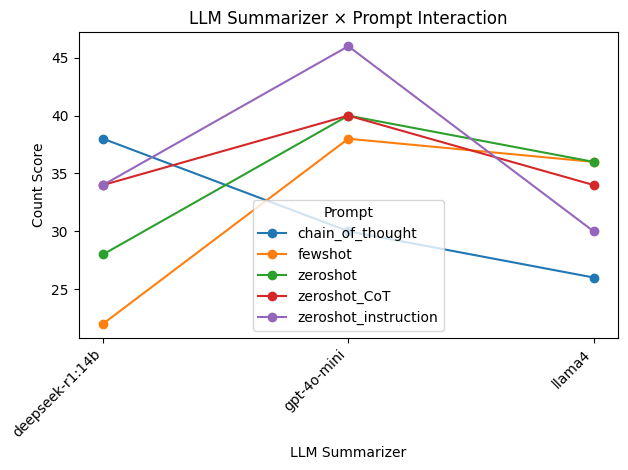

In [69]:
plt.figure()
for col in pivot_good.columns:
    plt.plot(pivot_good.index, pivot_good[col], marker="o", label=col)

plt.title("LLM Summarizer × Prompt Interaction")
plt.ylabel("Count Score")
plt.xlabel("LLM Summarizer")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Prompt")
plt.tight_layout()
plt.show()



gpt-4o-mini X zeroshot_instruction combination has the overall greatest performance
followed by gpt-4o-mini X zeroshot and gpt-4o-mini X zeroshot_CoT 
followed by deepseek-r1:14b X chain_of_thought......

gpt-4o-mini has a least performance with chain_of_thought but highest with zeroshot_instruction
deepseek-r1:14b has a least performance with fewshot but highest with chain_of_thought
llama4 has a least performance with chain_of_thought but highest with fewshot and zeroshot


### Resume
gpt-4o-mini take the lead in almost all the combination with the different prompt except with chain_of_thought
deepseek-r1:14b has the lowest performance when combine with fewshot, zeroshot and zeroshot_CoT, has the best performance with chain_of_thought and performed better than llama4 with zeroshot_instruction


     llm_summarizer  summarization_prompt label  count
1   deepseek-r1:14b      chain_of_thought  Good     38
4   deepseek-r1:14b               fewshot  Good     22
7   deepseek-r1:14b              zeroshot  Good     28
11  deepseek-r1:14b          zeroshot_CoT  Good     34
14  deepseek-r1:14b  zeroshot_instruction  Good     34
18      gpt-4o-mini      chain_of_thought  Good     30
21      gpt-4o-mini               fewshot  Good     38
25      gpt-4o-mini              zeroshot  Good     40
29      gpt-4o-mini          zeroshot_CoT  Good     40
32      gpt-4o-mini  zeroshot_instruction  Good     46
35           llama4      chain_of_thought  Good     26
38           llama4               fewshot  Good     36
41           llama4              zeroshot  Good     36
44           llama4          zeroshot_CoT  Good     34
47           llama4  zeroshot_instruction  Good     30


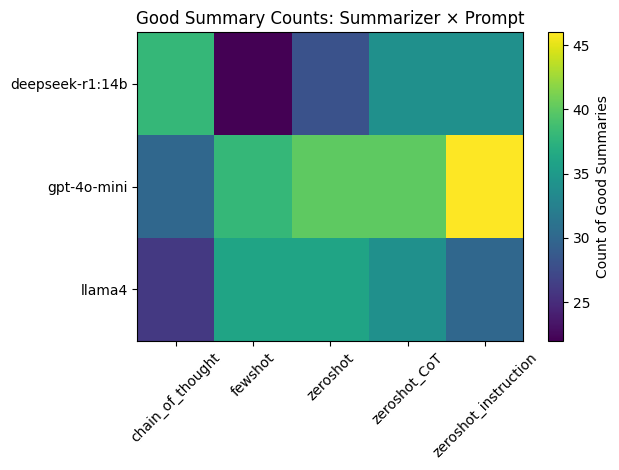

In [70]:
combo_counts = (
    df.groupby(["llm_summarizer", "summarization_prompt", "label"])
      .size()
      .reset_index(name="count")
)
#print(combo_counts)
good_only = combo_counts[combo_counts["label"] == "Good"]

print(good_only)
pivot_good = good_only.pivot(
    index="llm_summarizer",
    columns="summarization_prompt",
    values="count"
).fillna(0)

plt.imshow(pivot_good, aspect="auto")
plt.colorbar(label="Count of Good Summaries")
plt.xticks(range(len(pivot_good.columns)), pivot_good.columns, rotation=45)
plt.yticks(range(len(pivot_good.index)), pivot_good.index)
plt.title("Good Summary Counts: Summarizer × Prompt")
plt.tight_layout()
plt.show()


### RQ6: How consistent are judgements across judging LLMS?
this evaluation is done only if more than 1 judging_llm is used

label            Average  Excellent  Good  Poor
judging_llm                                    
deepseek-r1:14b      138         24   172    42
gpt-4o-mini           10          0   130     0
llama4               260          0   210    34
judging_llm
deepseek-r1:14b    0.457447
gpt-4o-mini        0.928571
llama4             0.416667
Name: Good, dtype: float64


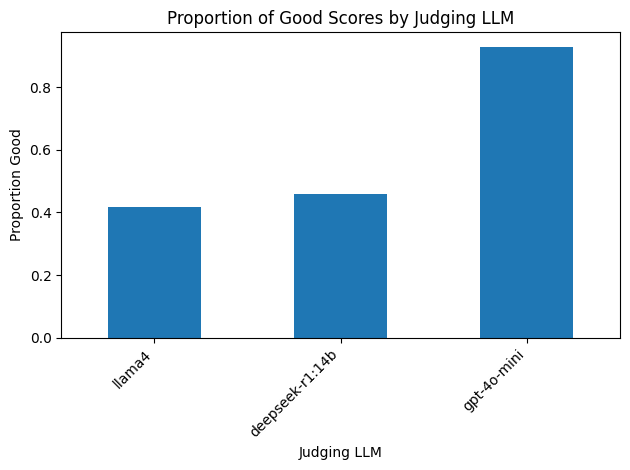

In [74]:
dist_judge = (
    df.groupby(["judging_llm", "label"])
      .size()
      .unstack(fill_value=0)
)
print(dist_judge )
judge_good_pct = dist_judge.div(dist_judge.sum(axis=1), axis=0)["Good"]

print(judge_good_pct)

plt.figure()
judge_good_pct.sort_values().plot(kind="bar")
plt.title("Proportion of Good Scores by Judging LLM")
plt.ylabel("Proportion Good")
plt.xlabel("Judging LLM")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Deepseek created it own judgement "Excellent", that was not defined in the judging prompt

In [64]:
avg_by_judge = (df.groupby(["judging_llm", "llm_summarizer" , "task", "label"])
                .size()
                .reset_index(name="count")
                )

print(avg_by_judge)
# plt.figure()
# avg_by_judge.plot(kind="bar")
# plt.title("Average Score by Judging LLM")
# plt.ylabel("Average Score")
# plt.xlabel("Judging LLM")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()


        judging_llm   llm_summarizer                  task    label  count
0   deepseek-r1:14b  deepseek-r1:14b        CLASSIFICATION  Average     14
1   deepseek-r1:14b  deepseek-r1:14b        CLASSIFICATION     Good     14
2   deepseek-r1:14b  deepseek-r1:14b        CLASSIFICATION     Poor      4
3   deepseek-r1:14b  deepseek-r1:14b            REGRESSION  Average     12
4   deepseek-r1:14b  deepseek-r1:14b            REGRESSION     Good     14
..              ...              ...                   ...      ...    ...
62           llama4           llama4            REGRESSION     Poor      2
63           llama4           llama4        SEMISUPERVISED  Average      4
64           llama4           llama4        SEMISUPERVISED     Good     36
65           llama4           llama4  TIME_SERIES_FORECAST  Average      4
66           llama4           llama4  TIME_SERIES_FORECAST     Good     36

[67 rows x 5 columns]


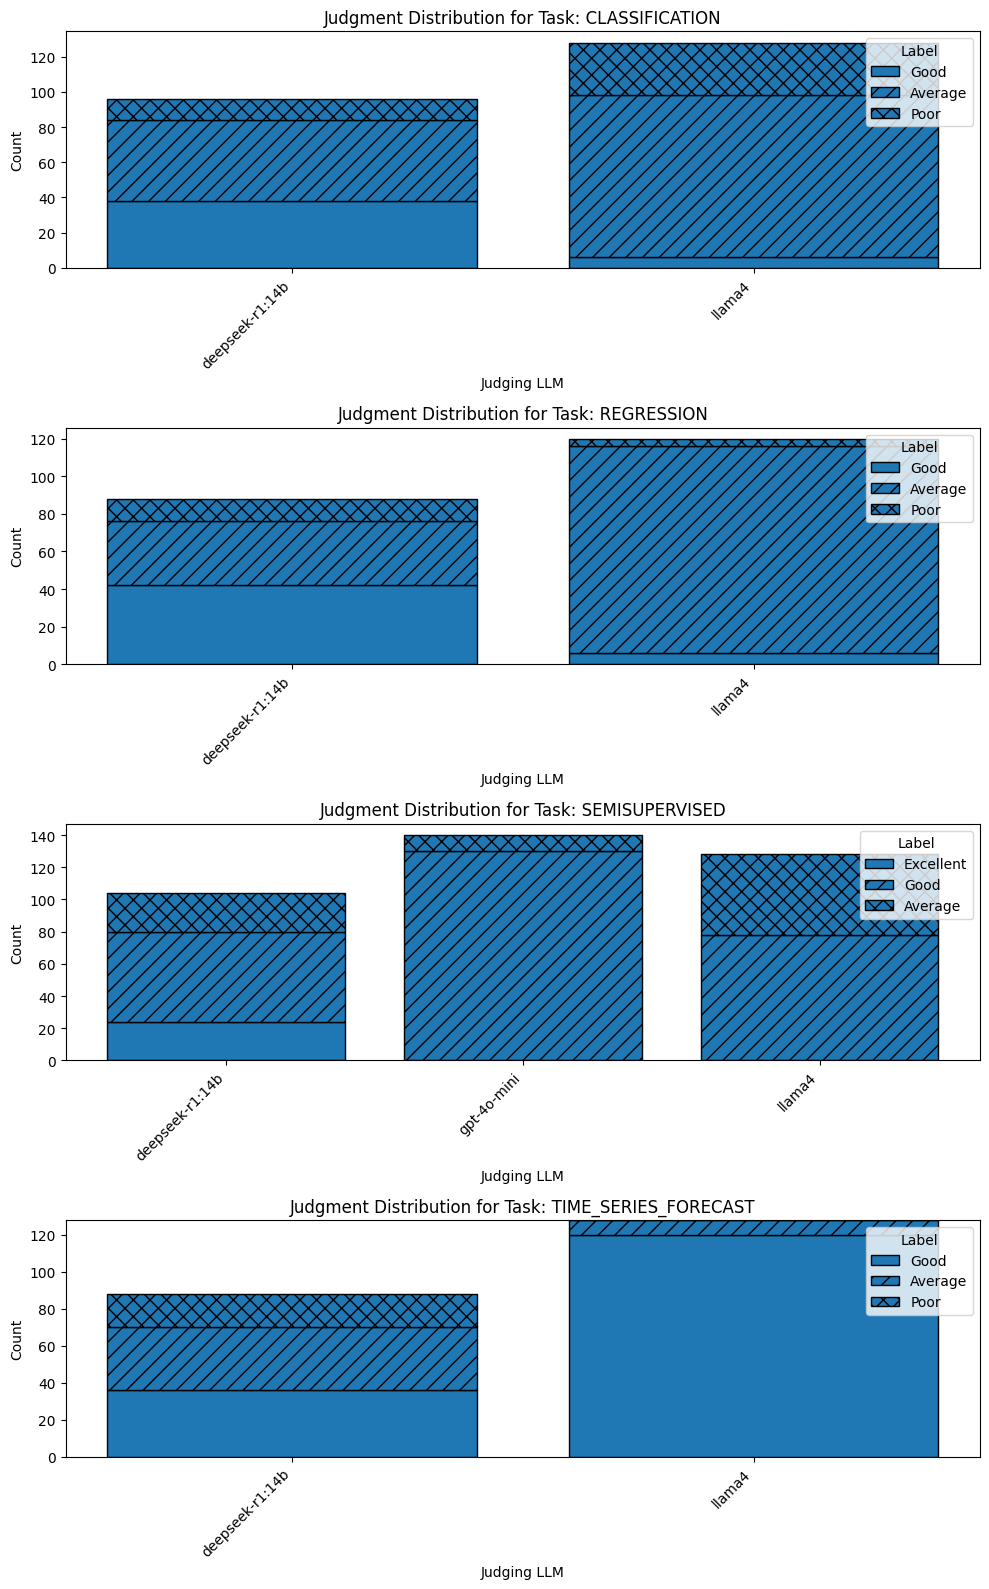

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Your grouped dataframe
avg_by_judge = (
    df.groupby(["judging_llm", "task", "label"])
      .size()
      .reset_index(name="count")
)

# Ensure consistent label order
label_order = ["Excellent", "Good", "Average", "Poor"]
hatches = ["", "//", "xx", "oo"]   # increasing density
color = "tab:blue"

tasks = avg_by_judge["task"].unique()

fig, axes = plt.subplots(nrows=len(tasks), ncols=1, figsize=(10, 4 * len(tasks)), sharex=False)

if len(tasks) == 1:
    axes = [axes]  # make iterable if only one task

for ax, task in zip(axes, tasks):
    task_df = avg_by_judge[avg_by_judge["task"] == task]

    pivot = (
        task_df.pivot(index="judging_llm", columns="label", values="count")
               .fillna(0)
    )

    # Enforce label order (drop missing ones safely)
    pivot = pivot[[lbl for lbl in label_order if lbl in pivot.columns]]

    bottom = pd.Series([0] * len(pivot), index=pivot.index)

    for i, label in enumerate(pivot.columns):
        bars = ax.bar(
            pivot.index,
            pivot[label],
            bottom=bottom,
            color=color,
            edgecolor="black",
            label=label
        )

        for bar in bars:
            bar.set_hatch(hatches[i])

        bottom += pivot[label]

    ax.set_title(f"Judgment Distribution for Task: {task}")
    ax.set_ylabel("Count")
    ax.set_xlabel("Judging LLM")
    ax.set_xticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.index, rotation=45, ha="right")

    ax.legend(title="Label", loc="upper right")

plt.tight_layout()
plt.show()


In [75]:
judging_score =  pd.crosstab(df["judging_llm"], [df["metric"], df["label"]], rownames=['judging_llm'], colnames=['metric','label']) 
judging_score

metric          Accuracy                     Clarity                      \
label            Average Excellent Good Poor Average Excellent Good Poor   
judging_llm                                                                
deepseek-r1:14b       42         8   42    2      44         6   20   24   
gpt-4o-mini            0         0   35    0       0         0   35    0   
llama4                80         0   46    0      86         0   38    2   

metric          Completeness                     Relevance                 
label                Average Excellent Good Poor   Average Excellent Good  
judging_llm                                                                
deepseek-r1:14b           48         2   28   16         4         8   82  
gpt-4o-mini               10         0   25    0         0         0   35  
llama4                    36         0   58   32        58         0   68

### RQ7: Do label distribution(Good/Bad/..) differ by model or prompt?
Use label frequencies to see qualitative differences beyond numeric score

                                                                           n_unique_labels
dataset         task                 llm_summarizer  summarization_prompt                 
196_autoMpg     REGRESSION           deepseek-r1:14b chain_of_thought                    3
                                                     fewshot                             1
                                                     zeroshot                            3
                                                     zeroshot_CoT                        2
                                                     zeroshot_instruction                3
                                     gpt-4o-mini     chain_of_thought                    2
                                                     fewshot                             3
                                                     zeroshot                            2
                                                     zeroshot_CoT                        2

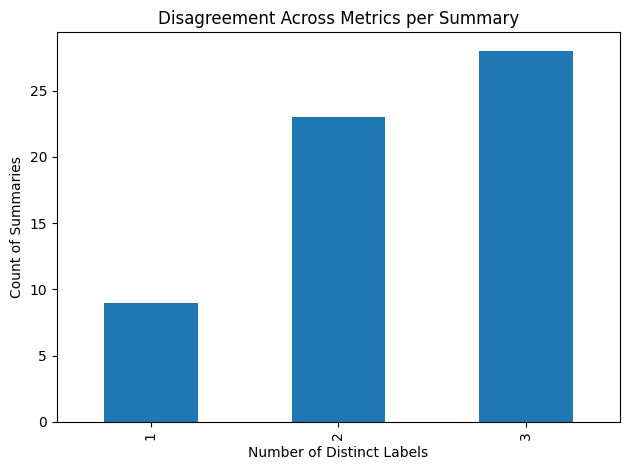

In [76]:
variation = (
    df.groupby(["dataset", "task", "llm_summarizer", "summarization_prompt"])
      .agg(n_unique_labels=("label", "nunique"))
)
print(variation)
plt.figure()
variation["n_unique_labels"].value_counts().sort_index().plot(kind="bar")

plt.title("Disagreement Across Metrics per Summary")
plt.xlabel("Number of Distinct Labels")
plt.ylabel("Count of Summaries")
plt.tight_layout()
plt.show()


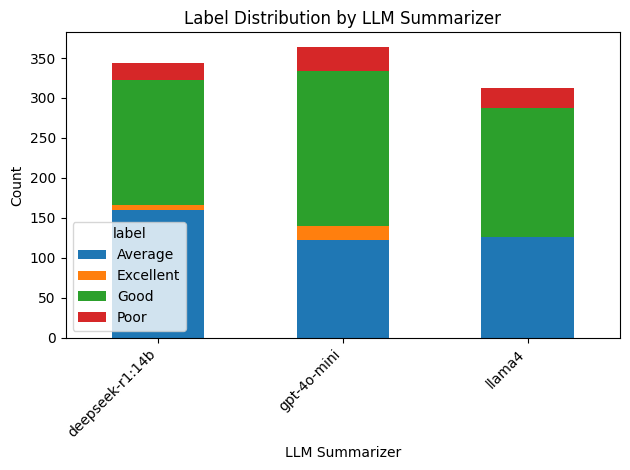

In [66]:
label_counts = df.groupby(["llm_summarizer", "label"]).size().unstack(fill_value=0)

label_counts.plot(kind="bar", stacked=True)
plt.title("Label Distribution by LLM Summarizer")
plt.ylabel("Count")
plt.xlabel("LLM Summarizer")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


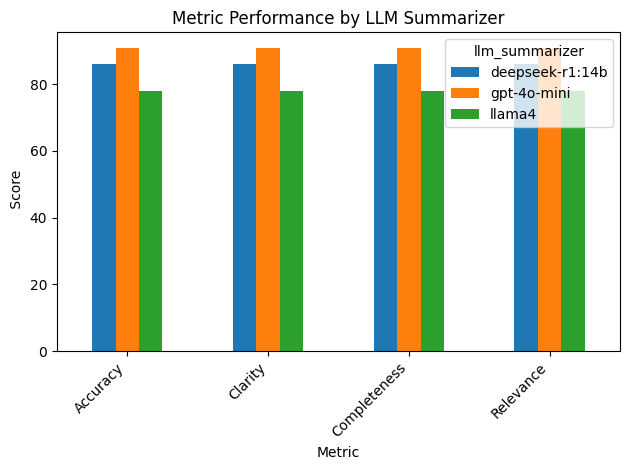

In [67]:
#Metric specific performance by Model

pivot_metric_model = pd.pivot_table(
    df,
    values="score",
    index="metric",
    columns="llm_summarizer",
    aggfunc="count"
)

pivot_metric_model.plot(kind="bar")
plt.title("Metric Performance by LLM Summarizer")
plt.ylabel(" Score")
plt.xlabel("Metric")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [17]:
# label_map = {1:"Good", 2:"Average", 3: "Poor"}
# df["label_text"] = df["score"].map(label_map)
# df["label_text"] 